In [16]:
# Enabling fast reload
%load_ext autoreload
%autoreload 2

# Importing
import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts')
from hicdatautils import import_cool, dist_weights, fetch_region
from hicvisutils import hic_vis_region

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# Importing cools
data_dir = "/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/taghic"
files = ["GSE152918_CLP.mcool", "GSE152918_CMP.mcool"]
clrs = []

for file in files:
    clrs.append(import_cool(f'{data_dir}/{file}', 1000000))

{'sum': np.int64(4438809), 'max': 21650, 'min': 1}

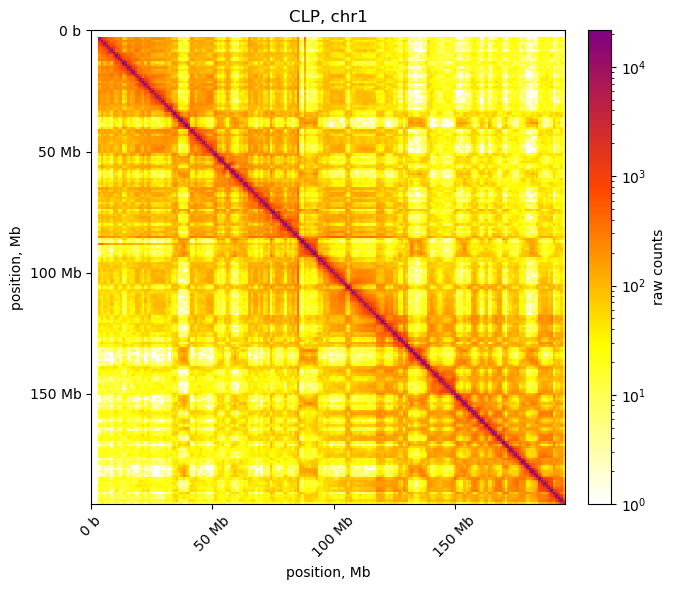

In [9]:
# Visualizing CLP
hic_vis_region(clrs[0], chrom="1", title="CLP, chr1", cmap="higlass")

{'sum': np.int64(1824194), 'max': 8580, 'min': 1}

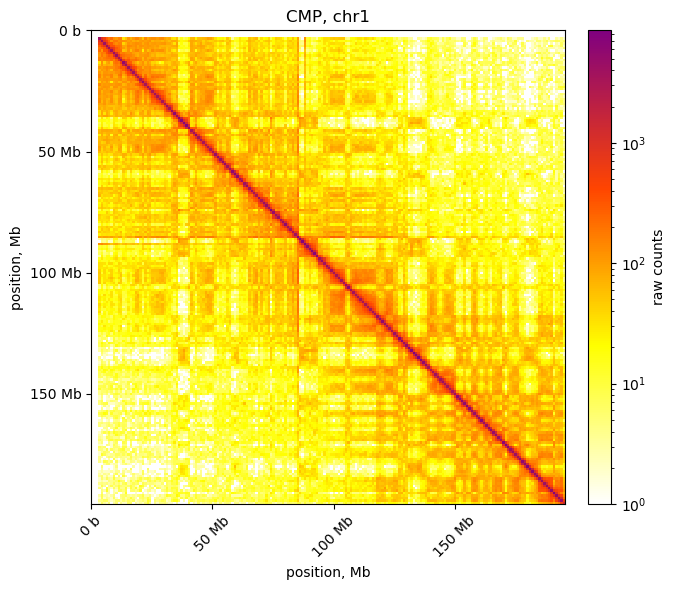

In [10]:
# Visualizing CMP
hic_vis_region(clrs[1], chrom="1", title="CMP, chr1", cmap="higlass")

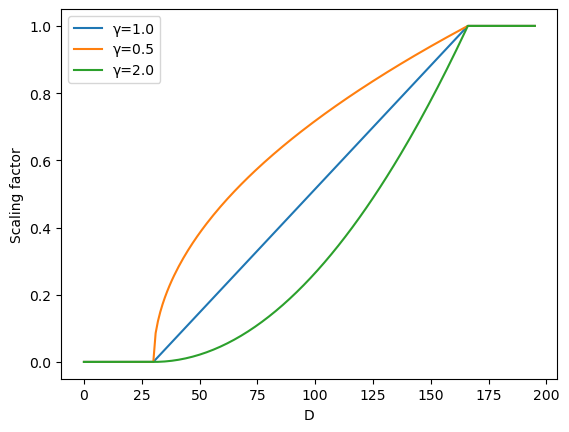

In [21]:
### Generating dist_weights explanation ###
chr1 = fetch_region(clrs[0], "1")
ref_chr = np.ones_like(chr1)
dist_scaled_1 = dist_weights(ref_chr, d0 = 30, d1=30)[0]
dist_scaled_05 = dist_weights(ref_chr, d0 = 30, d1=30, gamma=0.5)[0]
dist_scaled_2 = dist_weights(ref_chr, d0 = 30, d1=30, gamma=2)[0]
dists = np.arange(len(dist_scaled_1))

plt.plot(dists, dist_scaled_1, label="γ=1.0")
plt.plot(dists, dist_scaled_05, label="γ=0.5")
plt.plot(dists, dist_scaled_2, label="γ=2.0")
plt.xlabel("D")
plt.ylabel("Scaling factor")
plt.legend()